# Make figures

In [1]:
import xarray as xr
import rioxarray as rxr
import matplotlib.pyplot as plt
import glob

nairobi_wofs_freq.tif Water Observation Frequency (DE Africa)
nairobi_endisi_2016.tif Enhanced Normalized Difference Impervious Surfaces Index 2016 (Landsat)
nairobi_mrvbf.tif Multi-resolution Valley Bottom Flatness (DE Africa)
nairobi_lst_feb_2023_2025.tif Land Surface Temperature February 2023-2025 (Landsat)
nairobi_vv_2024.tif Sentinel-1 VV 2024 (DE Africa)
nairobi_lst_feb_2014_2017.tif Land Surface Temperature February 2014-2017 (Landsat)
nairobi_hrsl.tif High Resolution Population Density Maps (Meta)
nairobi_lst_mar_2023.tif Land Surface Temperature March 2023 (Landsat)
nairobi_elev.tif Elevation (SRTM)
nairobi_endisi_2024.tif Enhanced Normalized Difference Impervious Surfaces Index 2024 (Landsat)


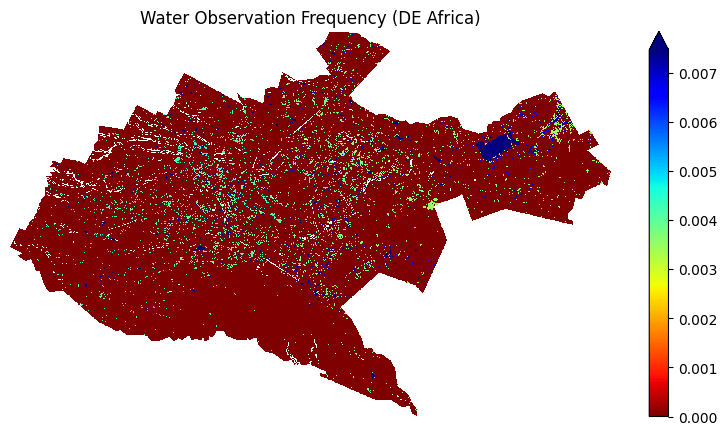

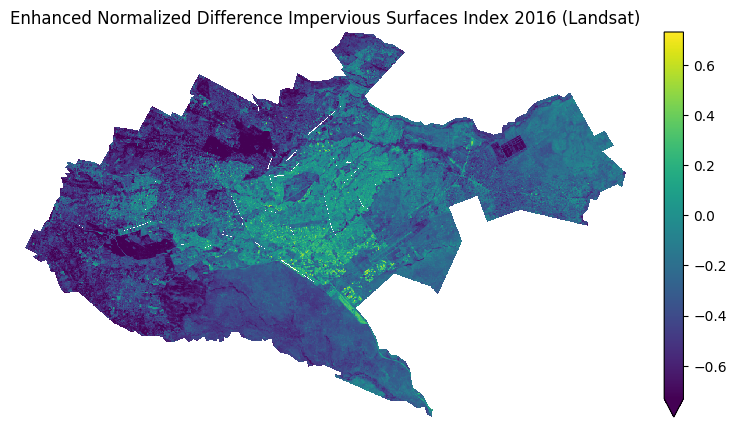

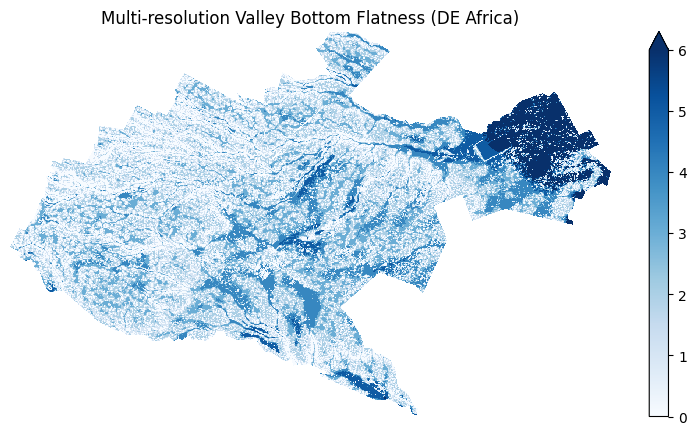

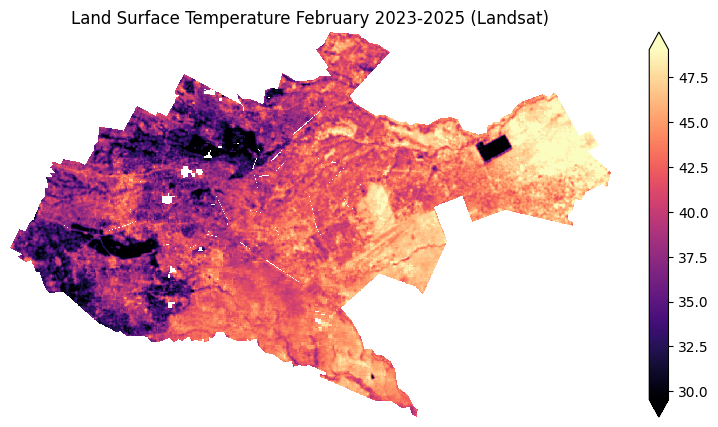

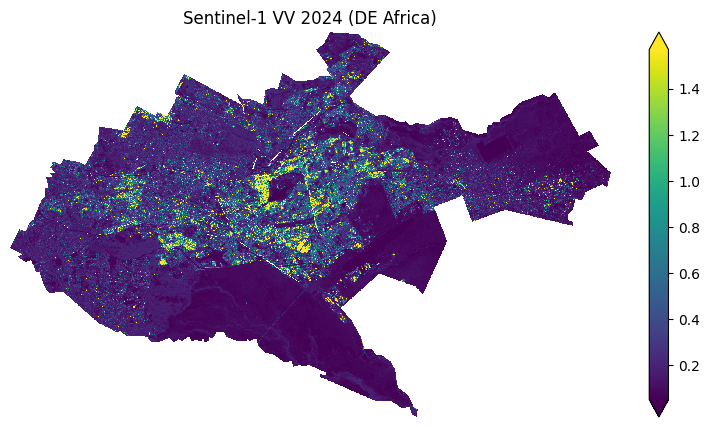

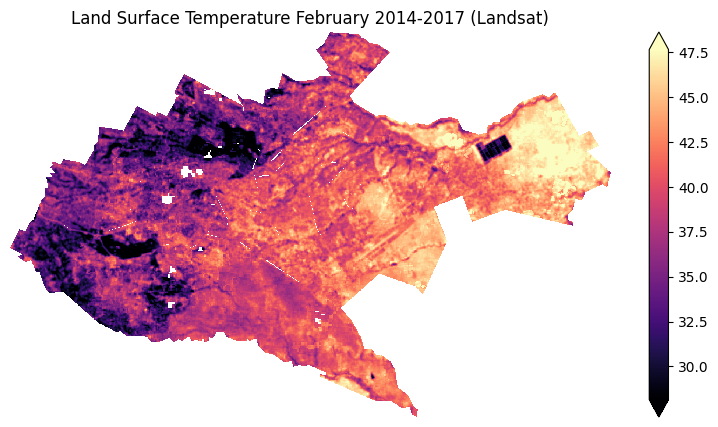

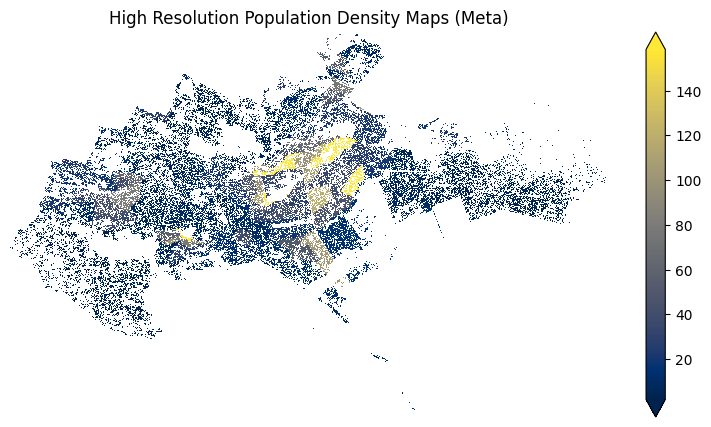

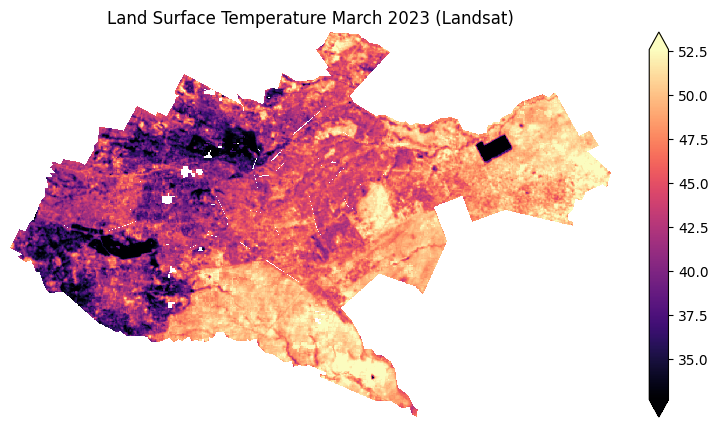

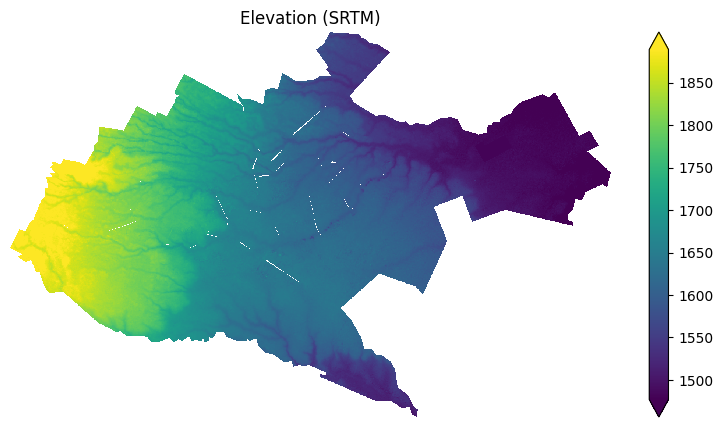

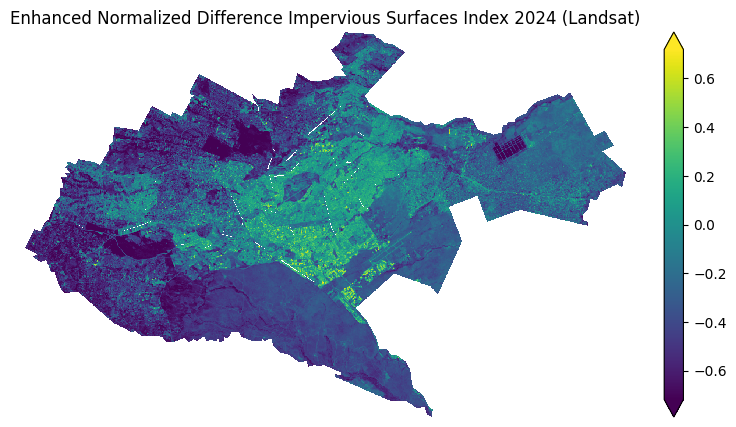

In [46]:
files = glob.glob('nairobi_*.tif')

for f in files:
    cmap ='viridis'
    title=''
    if 'endisi' in f: 
        #cmap='cividis'
        if '2024' in f: title='Enhanced Normalized Difference Impervious Surfaces Index 2024 (Landsat)'
        if '2016' in f: title='Enhanced Normalized Difference Impervious Surfaces Index 2016 (Landsat)'
    if 'hrsl' in f: 
        cmap='cividis'
        title='High Resolution Population Density Maps (Meta)'
    if 'lst' in f: 
        cmap='magma'
        if '2023' in f and 'feb' in f: title='Land Surface Temperature February 2023-2025 (Landsat)'
        if '2014' in f and 'feb' in f: title='Land Surface Temperature February 2014-2017 (Landsat)'
        if '2023' in f and 'mar' in f: title='Land Surface Temperature March 2023 (Landsat)'
    if 'wofs' in f: 
        cmap='jet_r'
        title='Water Observation Frequency (DE Africa)'
    if 'elev' in f:
        title='Elevation (SRTM)'
    if 'mrvbf' in f:
        cmap='Blues'
        title='Multi-resolution Valley Bottom Flatness (DE Africa)'
    if 'vv' in f:
        title='Sentinel-1 VV 2024 (DE Africa)'
    print(f, title)
    ds = rxr.open_rasterio(f).squeeze()
    ax = ds.plot.imshow(figsize=(10,5), robust=True, cmap=cmap);
    # Remove axes
    ax.axes.set_aspect('equal') 
    ax.axes.set_axis_off();
    ax.axes.set_title(title);
    plt.savefig(f.replace('.tif','.png'), dpi=300, bbox_inches='tight')

NameError: name 'title' is not defined

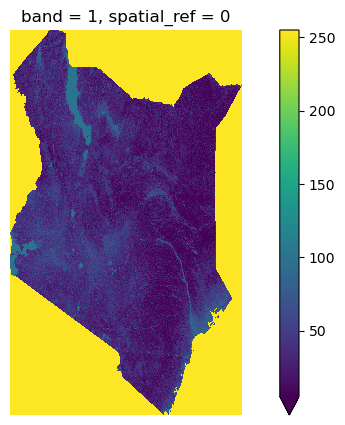

In [2]:
ds = rxr.open_rasterio('Kenya_wetland_binary_probabilities.tif').squeeze()
ax = ds.plot.imshow(figsize=(10,5), robust=True);
# Remove axes
ax.axes.set_aspect('equal') 
ax.axes.set_axis_off();
ax.axes.set_title(title);
#plt.savefig(f.replace('.tif','.png'), dpi=300, bbox_inches='tight')

In [47]:
ds = xr.concat([rxr.open_rasterio('nairobi_endisi_2016.tif').squeeze().expand_dims(time=["2016"]),
      rxr.open_rasterio('nairobi_endisi_2024.tif').squeeze().expand_dims(time=["2024"])], dim='time')

In [52]:
diff = (ds.sel(time='2024')-ds.sel(time='2016'))
change = diff.where(diff > diff.mean().values+2*diff.std().values)

In [53]:
change.rio.to_raster('endisi_diff.tif')

In [61]:
ds = xr.concat([rxr.open_rasterio('nairobi_lst_feb_2014_2017.tif').squeeze().expand_dims(time=["2016"]),
      rxr.open_rasterio('nairobi_lst_feb_2023_2025.tif').squeeze().expand_dims(time=["2024"])], dim='time')
diff = (ds.sel(time='2024')-ds.sel(time='2016'))
change = diff.where(diff > diff.mean().values+3*diff.std().values)
change.rio.to_raster('lst_diff.tif')

In [ ]:
from deafrica_tools.spatial import xr_rasterize, xr_vectorize
change.xr_vectorize

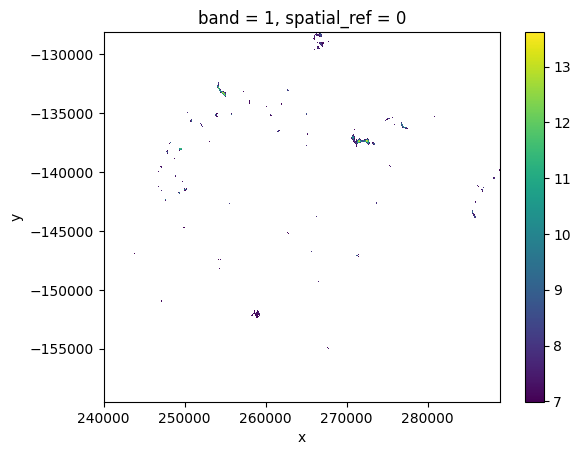

In [62]:
change.plot.imshow()

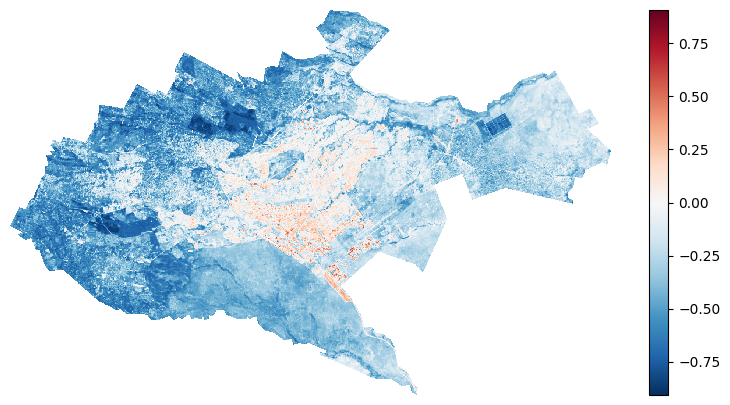

In [25]:
ax = ds.isel(time=0).plot.imshow(figsize=(10,5));
# Remove axes
ax.axes.set_aspect('equal') 
ax.axes.set_axis_off();
ax.axes.set_title('');
plt.savefig("test.png", dpi=300, bbox_inches='tight')

NameError: name 'da' is not defined

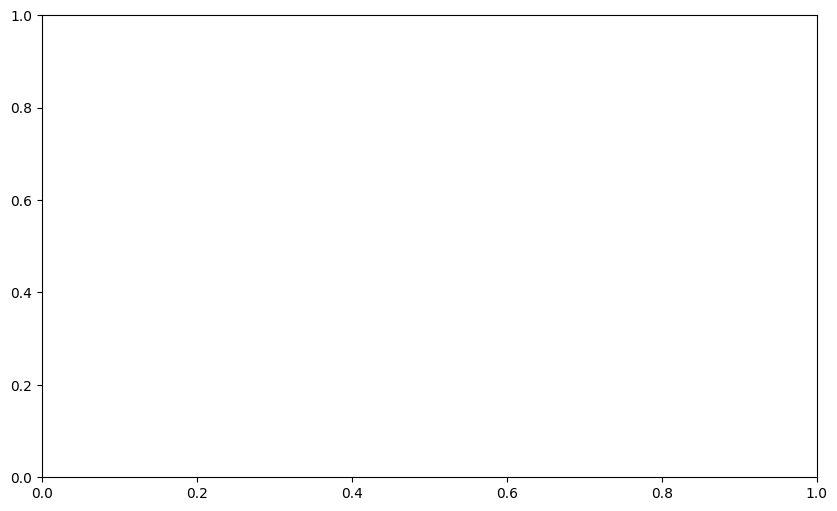

In [8]:
# Plot using xarray (which uses matplotlib under the hood)
fig = plt.figure(figsize=(10, 6))  # Adjust size in inches
ax = fig.add_subplot(1, 1, 1)
da.plot(ax=ax)

# Save as high-res PNG
#plt.savefig("high_res_map.png", dpi=300, bbox_inches='tight')

In [ ]:
# Example: open a dataset and select a variable
ds = xr.open_dataset("your_data.nc")
da = ds["your_variable"]


